# Analytics Module
The Analytics module provides descriptive statistics on content data, evidence data and model evaluations 

In [10]:
# reloads modules automatically before entering the execution of code
%load_ext autoreload
%autoreload 2

# third parties imports
import numpy as np 
import pandas as pd
# -- add new imports here --
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
# local imports
from constants import Constant as C
from loaders import load_ratings
from loaders import load_items

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1 - Content analytics
Explore and perform descriptive statistics on content data

In [11]:
# -- load the items and display the Dataframe

df_items = load_items()
display(df_items)

,title,genres
movieId,,
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,Jumanji (1995),Adventure|Children|Fantasy
3,Grumpier Old Men (1995),Comedy|Romance
4,Waiting to Exhale (1995),Comedy|Drama|Romance
5,Father of the Bride Part II (1995),Comedy
...,...,...
161582,Hell or High Water (2016),Crime|Drama
161594,Kingsglaive: Final Fantasy XV (2016),Action|Adventure|Animation|Drama|Fantasy|Sci-Fi
161918,Sharknado 4: The 4th Awakens (2016),Action|Adventure|Horror|Sci-Fi


In [12]:
# -- display relevant informations that can be extracted from the dataset

# The number of movies
n_movies = len(df_items)
print(f"Number of movies: {n_movies}")

# Year range 
df_items['year'] = df_items[C.LABEL_COL].str.extract(r'\((\d{4})\)').astype(float)
min_year = df_items['year'].min()
max_year = df_items['year'].max()
print(f"Year range: {int(min_year)} - {int(max_year)}")

# List of unique movie genres
genres_list = df_items[C.GENRES_COL].str.split('|').explode().unique()
print(f"Movie genres: {list(genres_list)}")

Number of movies: 8737
Year range: 1902 - 2016
Movie genres: ['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy', 'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror', 'Mystery', 'Sci-Fi', 'Documentary', 'IMAX', 'War', 'Musical', 'Western', 'Film-Noir', '(no genres listed)']


# 2 - Evidence analytics
Explore and perform descriptive statistics on evidence data

In [13]:
# -- load the items and display the Dataframe

df_ratings = load_ratings()
display(df_ratings)

,userId,movieId,rating,timestamp
0,277,6,5.0,836983211
1,277,7,5.0,851419421
2,277,10,3.0,836982963
3,277,16,5.0,836983252
4,277,18,3.0,836984035
...,...,...,...,...
381176,283184,5553,2.0,1042416423
381177,283184,5673,5.0,1042414496
381178,283184,5689,3.0,1042414792
381179,283184,5902,5.0,1042414483


In [14]:
# -- display relevant informations that can be extracted from the dataset

# (A) The total number of rating 
total_ratings = len(df_ratings[C.RATING_COL])
print(f"Total number of ratings: {total_ratings}")

# (B) The number of unique users
n_unique_users = df_ratings[C.USER_ID_COL].nunique() 
print(f"Number of unique users: {n_unique_users}")

# (C) The number of unique movies (in the ratings matrix)
n_unique_movies = df_ratings[C.ITEM_ID_COL].nunique() 
print(f"Number of unique movies: {n_unique_movies}")

# (D) The number of ratings of the most rated movie(s) 
# (E) The number of ratings of the less rated movie(s)
ratings_per_movie = df_ratings.groupby(C.ITEM_ID_COL).size()
max_ratings = ratings_per_movie.max()
min_ratings = ratings_per_movie.min()
print(f"Number of ratings of the most rated movie: {max_ratings}")
print(f"Number of ratings of the least rated movie: {min_ratings}")

# (F) All the possible rating values, from smallest value to value highest
rating_values = sorted([float(v) for v in df_ratings[C.RATING_COL].unique()])
print(f"All possible rating values: {rating_values}")

# (G) The number of movies that were not rated at all
catalog_ids = set(df_items.index) 
rated_ids = set(df_ratings[C.ITEM_ID_COL])
not_rated_count = len(catalog_ids - rated_ids)
print(f"Number of movies that were not rated at all: {not_rated_count}")

Total number of ratings: 381181
Number of unique users: 1000
Number of unique movies: 8737
Number of ratings of the most rated movie: 837
Number of ratings of the least rated movie: 1
All possible rating values: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
Number of movies that were not rated at all: 0


# 3 - Long-tail property

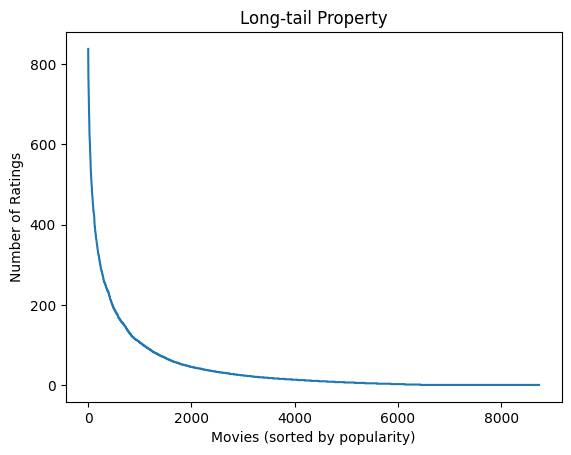

In [15]:
# (1) Count the number of ratings per movie
movie_counts = df_ratings[C.ITEM_ID_COL].value_counts()

# (2) Sort the counts from highest to lowest
sorted_counts = movie_counts.sort_values(ascending=False).values

# (3) Simple plot
plt.plot(sorted_counts)
plt.title("Long-tail Property")
plt.xlabel("Movies (sorted by popularity)")
plt.ylabel("Number of Ratings")
plt.show()

# 4 - Ratings matrix sparsity

Matrix sparsity: 95.64%


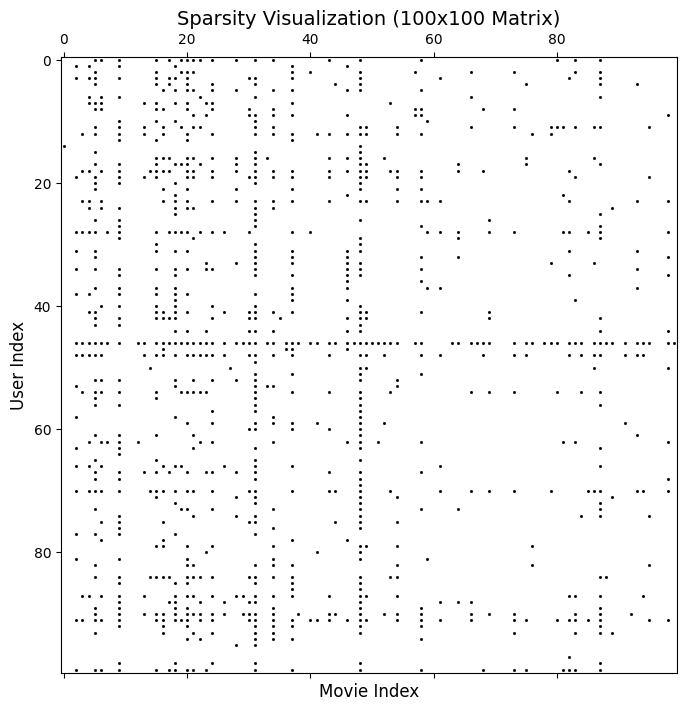

In [16]:
# STEP 1 : Create the Sparse Matrix
def create_X(df):
    M = df[C.USER_ID_COL].nunique()
    N = df[C.ITEM_ID_COL].nunique()

    user_mapper = dict(zip(np.unique(df[C.USER_ID_COL]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df[C.ITEM_ID_COL]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df[C.USER_ID_COL])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df[C.ITEM_ID_COL])))

    user_index = [user_mapper[i] for i in df[C.USER_ID_COL]]
    item_index = [movie_mapper[i] for i in df[C.ITEM_ID_COL]]

    X = csr_matrix((df[C.RATING_COL], (user_index, item_index)), shape=(M, N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

# Generate the matrix using the ratings dataframe
X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(df_ratings)


# STEP 2 : Compute Sparsity Metric
n_total = X.shape[0] * X.shape[1]  # Total cells (Users * Movies)
n_ratings = X.nnz                  # Number of specified ratings
sparsity_metric = 1 - (n_ratings / n_total)

print(f"Matrix sparsity: {round(sparsity_metric * 100, 2)}%")


# STEP 3 : Visual Observation with .spy()
# Create the plot
plt.figure(figsize=(8, 8))

# We slice the first 100 rows and 100 columns of X
plt.spy(X[:100, :100], markersize=1, color='black')

plt.title("Sparsity Visualization (100x100 Matrix)", fontsize=14)
plt.xlabel("Movie Index", fontsize=12)
plt.ylabel("User Index", fontsize=12)

plt.show()


# 5 - Visual Comparison of Models

Comparison of all latent factor models across all evaluation metrics.
RMSE/MAE are excluded for iALS and BPR (not meaningful for these models).

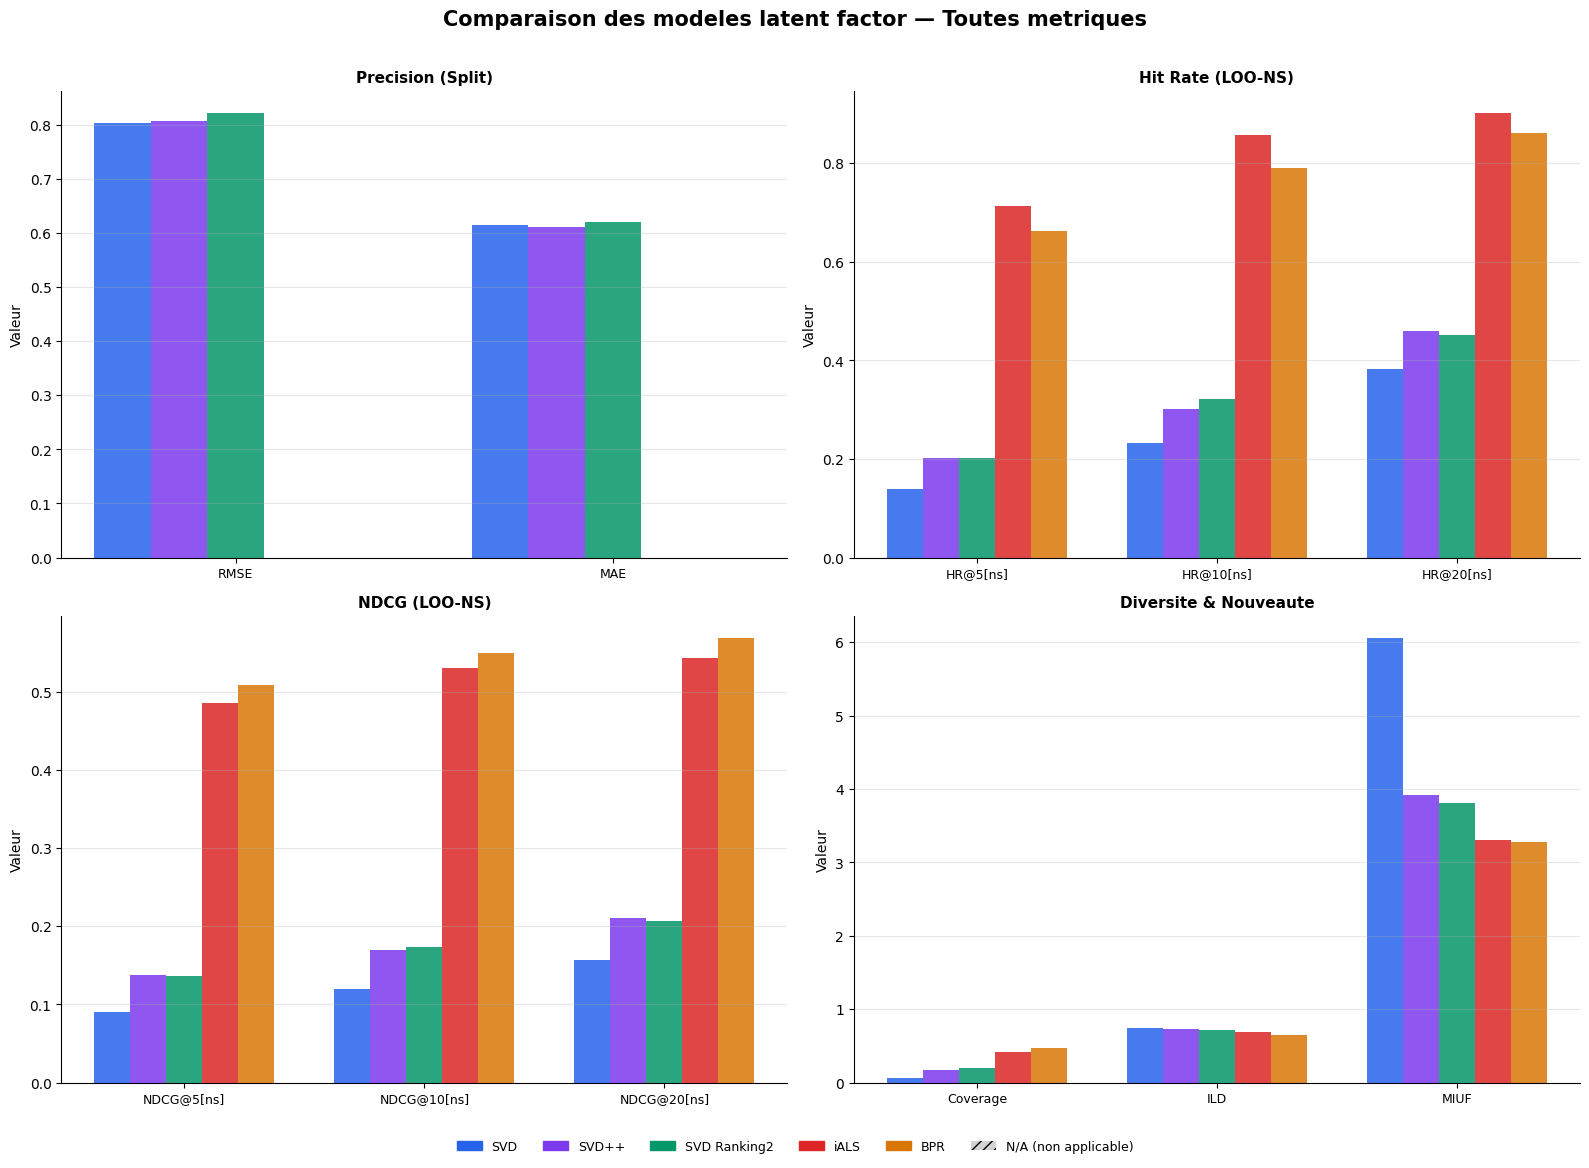

Sources : evaluations 2026-05-27 et 2026-05-28 — protocole LOO + 99 negatifs (He et al. 2017, WWW)


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Consolidated data (evaluations 2026-05-27 and 2026-05-28)
data = {
    'Modele':      ['SVD', 'SVD++', 'SVD Ranking2', 'iALS', 'BPR'],
    'RMSE':        [0.804, 0.806, 0.822, None, None],
    'MAE':         [0.614, 0.611, 0.621, None, None],
    'HR@5[ns]':    [0.138, 0.202, 0.201, 0.713, 0.663],
    'HR@10[ns]':   [0.233, 0.302, 0.321, 0.856, 0.790],
    'HR@20[ns]':   [0.382, 0.459, 0.451, 0.902, 0.862],
    'NDCG@5[ns]':  [0.090, 0.138, 0.136, 0.485, 0.509],
    'NDCG@10[ns]': [0.120, 0.170, 0.174, 0.531, 0.550],
    'NDCG@20[ns]': [0.157, 0.210, 0.207, 0.543, 0.569],
    'Coverage':    [0.062, 0.175, 0.194, 0.422, 0.473],
    'MIUF':        [6.060, 3.920, 3.810, 3.300, 3.280],
    'ILD':         [0.738, 0.730, 0.718, 0.691, 0.653],
}
df = pd.DataFrame(data).set_index('Modele')

groups = {
    'Accuracy (Split)':     ['RMSE', 'MAE'],
    'Hit Rate (LOO-NS)':     ['HR@5[ns]', 'HR@10[ns]', 'HR@20[ns]'],
    'NDCG (LOO-NS)':         ['NDCG@5[ns]', 'NDCG@10[ns]', 'NDCG@20[ns]'],
    'Diversity & Novelty': ['Coverage', 'ILD', 'MIUF'],
}

colors = ['#2563EB', '#7C3AED', '#059669', '#DC2626', '#D97706']
models = df.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Comparaison des modeles latent factor — Toutes metriques',
             fontsize=15, fontweight='bold', y=1.01)

for ax, (group_name, metrics) in zip(axes.flat, groups.items()):
    x     = np.arange(len(metrics))
    n     = len(models)
    width = 0.15
    offset = np.linspace(-(n-1)/2, (n-1)/2, n) * width

    for j, (model, color) in enumerate(zip(models, colors)):
        vals = [df.loc[model, m] if pd.notna(df.loc[model, m]) else 0 for m in metrics]
        bars = ax.bar(x + offset[j], vals, width, label=model, color=color, alpha=0.85)
        for k, (bar, v) in enumerate(zip(bars, vals)):
            if pd.isna(df.loc[model, metrics[k]]):
                bar.set_hatch('///')
                bar.set_facecolor('lightgray')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_title(group_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Valeur')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

handles = [mpatches.Patch(color=c, label=m) for c, m in zip(colors, models)]
na_patch = mpatches.Patch(facecolor='lightgray', hatch='///', label='N/A (not applicable)')
fig.legend(handles=handles + [na_patch], loc='lower center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.show()
print("Sources: evaluations 2026-05-27 and 2026-05-28 — LOO + 99 negatives protocol (He et al. 2017, WWW)")


# 6 - Accuracy vs Diversity Trade-off

Visualisation of the trade-off between ranking quality (HR@10[ns]) and diversity/coverage (ILD, Coverage).
This chart justifies having two different models for two different carousels:
- A model with good HR@k for "Top Picks For You" (iALS)
- A model with good coverage for "Discover Something New" (BPR)

**References:** Vargas & Castells (2011, SIGIR) · Kunaver & Pozrl (2017, IS) · He et al. (2017, WWW)

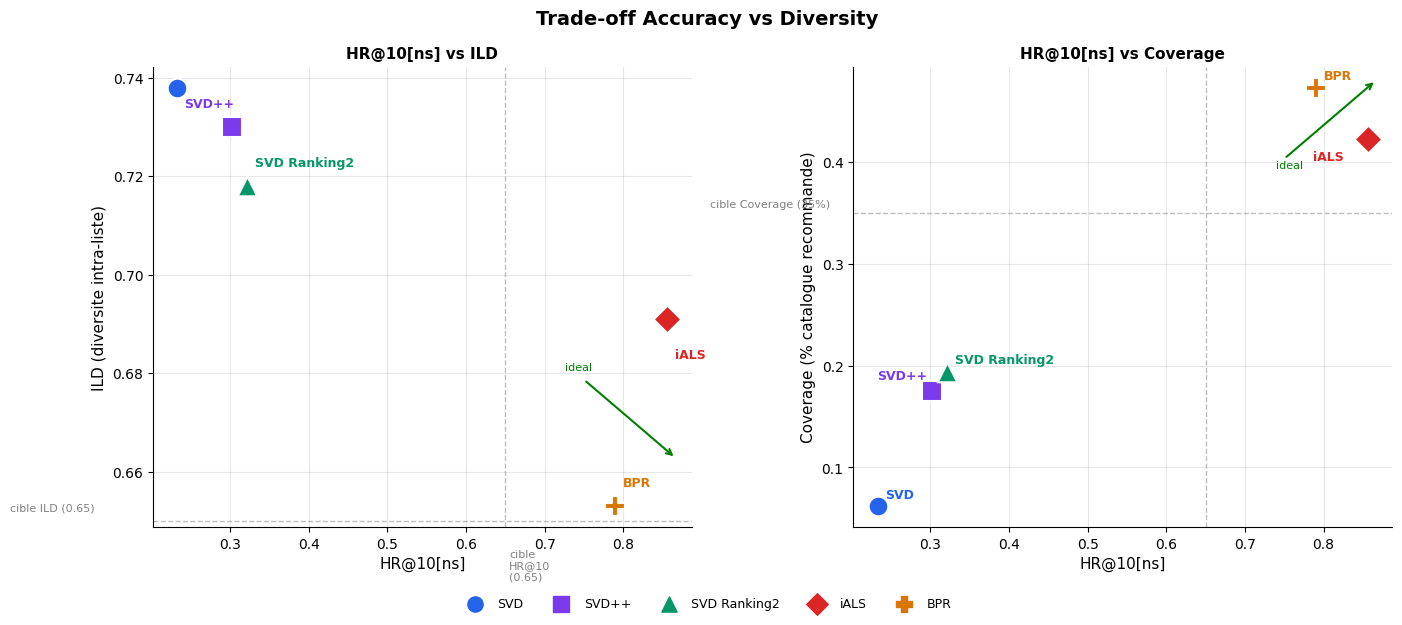

Lecture : coin superieur droit = meilleur HR@k ET meilleure coverage/ILD
iALS et BPR dominent SVD/SVD++/SVD Ranking2 sur les deux axes.
La separation iALS (ILD superieur) vs BPR (Coverage superieure) justifie deux carousels distincts.


In [18]:
import matplotlib.pyplot as plt
import numpy as np

models_td = ['SVD', 'SVD++', 'SVD Ranking2', 'iALS', 'BPR']
colors_td  = ['#2563EB', '#7C3AED', '#059669', '#DC2626', '#D97706']
markers    = ['o', 's', '^', 'D', 'P']

hr10 = [0.233, 0.302, 0.321, 0.856, 0.790]
ild  = [0.738, 0.730, 0.718, 0.691, 0.653]
cov  = [0.062, 0.175, 0.194, 0.422, 0.473]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Trade-off Accuracy vs Diversity', fontsize=14, fontweight='bold')

label_offsets_1 = {
    'SVD':          (-0.055,  0.004),
    'SVD++':        (-0.060,  0.004),
    'SVD Ranking2': ( 0.010,  0.004),
    'iALS':         ( 0.010, -0.008),
    'BPR':          ( 0.010,  0.004),
}
label_offsets_2 = {
    'SVD':          ( 0.010,  0.008),
    'SVD++':        (-0.070,  0.012),
    'SVD Ranking2': ( 0.010,  0.008),
    'iALS':         (-0.070, -0.020),
    'BPR':          ( 0.010,  0.008),
}

# Graphique 1 : HR@10[ns] vs ILD
ax1 = axes[0]
for i, (m, c, mk) in enumerate(zip(models_td, colors_td, markers)):
    ax1.scatter(hr10[i], ild[i], s=200, color=c, marker=mk, zorder=5,
                edgecolors='white', linewidths=1.5, label=m)
    dx, dy = label_offsets_1[m]
    ax1.annotate(m, (hr10[i] + dx, ild[i] + dy), fontsize=9, color=c, fontweight='bold')

ax1.axhline(0.65, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(0.65, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.text(0.02, 0.652, 'ILD target (0.65)', fontsize=8, color='gray')
ax1.text(0.655, 0.638, 'HR@10\ntarget\n(0.65)', fontsize=8, color='gray')
ax1.set_xlabel('HR@10[ns]', fontsize=11)
ax1.set_ylabel('ILD (diversite intra-liste)', fontsize=11)
ax1.set_title('HR@10[ns] vs ILD', fontsize=11, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# Zone ideale
ax1.annotate('', xy=(0.97, 0.15), xytext=(0.80, 0.32),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax1.text(0.79, 0.34, 'ideal', transform=ax1.transAxes,
         fontsize=8, color='green', ha='center')

# Graphique 2 : HR@10[ns] vs Coverage
ax2 = axes[1]
for i, (m, c, mk) in enumerate(zip(models_td, colors_td, markers)):
    ax2.scatter(hr10[i], cov[i], s=200, color=c, marker=mk, zorder=5,
                edgecolors='white', linewidths=1.5, label=m)
    dx, dy = label_offsets_2[m]
    ax2.annotate(m, (hr10[i] + dx, cov[i] + dy), fontsize=9, color=c, fontweight='bold')

ax2.axhline(0.35, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.axvline(0.65, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.text(0.02, 0.355, 'Coverage target (35%)', fontsize=8, color='gray')
ax2.set_xlabel('HR@10[ns]', fontsize=11)
ax2.set_ylabel('Coverage (% catalogue recommande)', fontsize=11)
ax2.set_title('HR@10[ns] vs Coverage', fontsize=11, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

ax2.annotate('', xy=(0.97, 0.97), xytext=(0.80, 0.80),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax2.text(0.81, 0.78, 'ideal', transform=ax2.transAxes,
         fontsize=8, color='green', ha='center')

handles = [plt.scatter([], [], s=120, color=c, marker=mk, label=m)
           for m, c, mk in zip(models_td, colors_td, markers)]
fig.legend(handles=handles, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.show()

print("Reading: top-right corner = best HR@k AND best coverage/ILD")
print("iALS and BPR dominate SVD/SVD++/SVD Ranking2 on both axes.")
print("The iALS (higher ILD) vs BPR (higher Coverage) split justifies two distinct carousels.")


# 7 - Carousel Overlap (iALS vs BPR)

Measures the proportion of films in common between the two main carousels:
**Top Picks For You** (iALS) and **Discover Something New** (BPR).

A low overlap validates the usefulness of having two distinct carousels.

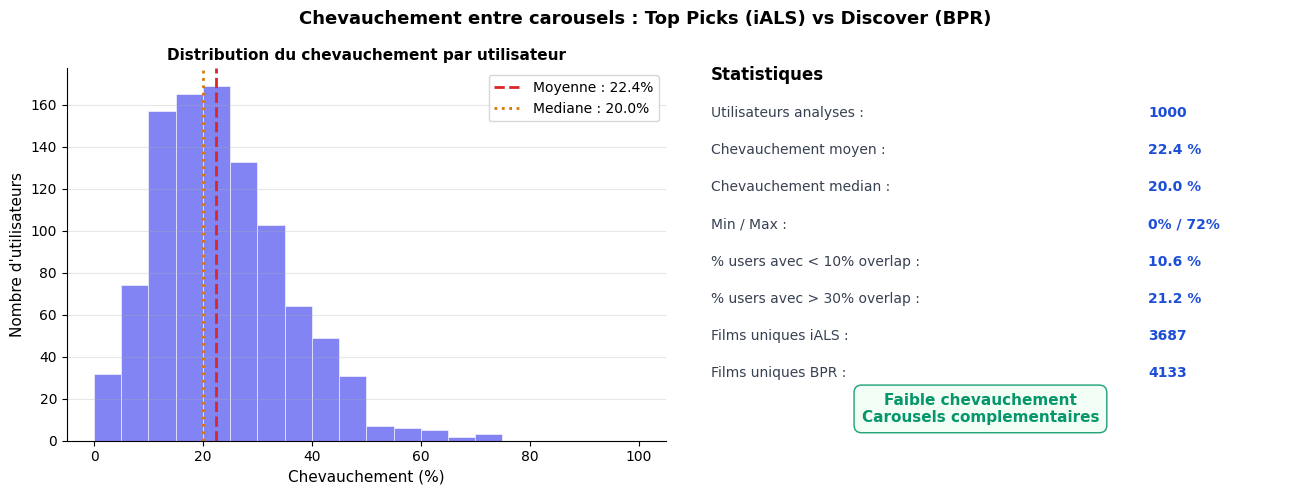

In [21]:
from models import ModeliALS, ModelBPR, get_top_n

sp_ratings = load_ratings(surprise_format=True)
trainset   = sp_ratings.build_full_trainset()

print('Training iALS...')
ials_model = ModeliALS(factors=50, iterations=20, regularization=0.01, alpha=40)
ials_model.fit(trainset)
ials_top_n = get_top_n(ials_model.test(trainset.build_anti_testset()), n=40)

print('Training BPR...')
bpr_model  = ModelBPR(factors=64, learning_rate=0.01, regularization=0.01, iterations=100)
bpr_model.fit(trainset)
bpr_top_n  = get_top_n(bpr_model.test(trainset.build_anti_testset()), n=40)

common_users = set(ials_top_n.keys()) & set(bpr_top_n.keys())
overlaps = []
for uid in common_users:
    ials_set = set(iid for iid, _ in ials_top_n[uid])
    bpr_set  = set(iid for iid, _ in bpr_top_n[uid])
    overlaps.append(len(ials_set & bpr_set) / 40 * 100)
overlaps = np.array(overlaps)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Carousel overlap: Top Picks (iALS) vs Discover (BPR)', fontsize=13, fontweight='bold')
ax1 = axes[0]
ax1.hist(overlaps, bins=np.arange(0, 101, 5), color='#6366F1', alpha=0.8, edgecolor='white', linewidth=0.5)
ax1.axvline(overlaps.mean(),     color='#DC2626', linestyle='--', linewidth=2, label=f'Mean: {overlaps.mean():.1f}%')
ax1.axvline(np.median(overlaps), color='#D97706', linestyle=':',  linewidth=2, label=f'Median: {np.median(overlaps):.1f}%')
ax1.set_xlabel('Chevauchement (%)', fontsize=11)
ax1.set_ylabel("Number of users", fontsize=11)
ax1.set_title('Overlap distribution per user', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)
ax2 = axes[1]
ax2.axis('off')
stats = [('Users analysed', f'{len(overlaps)}'),
         ('Mean overlap', f'{overlaps.mean():.1f} %'),
         ('Median overlap', f'{np.median(overlaps):.1f} %'),
         ('Min / Max', f'{overlaps.min():.0f}% / {overlaps.max():.0f}%'),
         ('% users < 10% overlap', f'{(overlaps < 10).mean()*100:.1f} %'),
         ('% users > 30% overlap', f'{(overlaps > 30).mean()*100:.1f} %'),
         ('Unique films iALS', str(len({i for recs in ials_top_n.values() for i,_ in recs}))),
         ('Unique films BPR',  str(len({i for recs in bpr_top_n.values()  for i,_ in recs})))]
ax2.text(0.05, 0.97, 'Statistics', fontsize=12, fontweight='bold', transform=ax2.transAxes)
for k, (label, val) in enumerate(stats):
    y = 0.87 - k * 0.10
    ax2.text(0.05, y, label + ' :', fontsize=10, transform=ax2.transAxes, color='#374151')
    ax2.text(0.78, y, val, fontsize=10, transform=ax2.transAxes, fontweight='bold', color='#1D4ED8')
verdict_ok = overlaps.mean() < 25
vc = '#059669' if verdict_ok else '#DC2626'
vt = 'Low overlap\nComplementary carousels' if verdict_ok else 'High overlap\nCarousels too similar'
ax2.text(0.5, 0.05, vt, fontsize=11, transform=ax2.transAxes, color=vc, fontweight='bold', ha='center',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0FDF4' if verdict_ok else '#FEF2F2', edgecolor=vc, alpha=0.9))
plt.tight_layout()
plt.show()


# 8 - User Activity Distribution

Histogram of the number of ratings per user.
Identifies the proportion of cold-start users (< 20 ratings) vs power users (>= 200 ratings).
Systematically present in RecSys papers to characterise the dataset.

**Reference:** He et al. (2017, WWW) · Kang & McAuley (2018, ICDM) — Dataset Statistics section

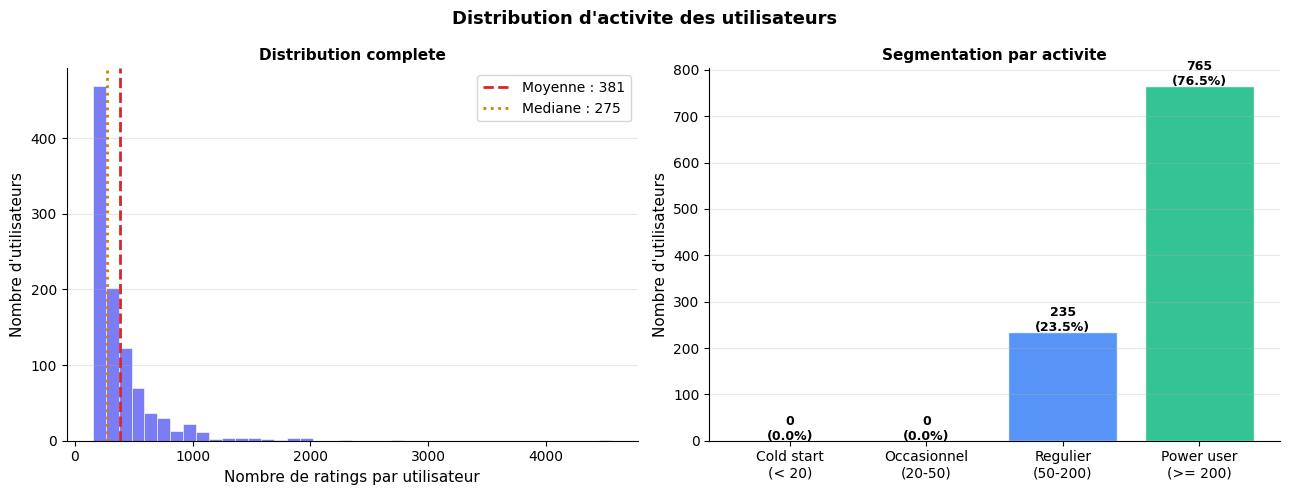

Total utilisateurs   : 1000
Moyenne ratings/user : 381.2
Mediane ratings/user : 275


In [22]:
user_activity = df_ratings.groupby(C.USER_ID_COL).size().reset_index(name='n_ratings')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("User Activity Distribution", fontsize=13, fontweight='bold')
ax1 = axes[0]
ax1.hist(user_activity['n_ratings'], bins=40, color='#6366F1', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.axvline(user_activity['n_ratings'].mean(),   color='#DC2626', linestyle='--', linewidth=2, label=f"Mean: {user_activity['n_ratings'].mean():.0f}")
ax1.axvline(user_activity['n_ratings'].median(), color='#D97706', linestyle=':',  linewidth=2, label=f"Median: {user_activity['n_ratings'].median():.0f}")
ax1.set_xlabel('Number of ratings per user', fontsize=11)
ax1.set_ylabel("Number of users", fontsize=11)
ax1.set_title('Full distribution', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)
ax2 = axes[1]
segments = {'Cold start\n(< 20)':   (user_activity['n_ratings'] < 20).sum(),
            'Occasional\n(20-50)':  ((user_activity['n_ratings'] >= 20) & (user_activity['n_ratings'] < 50)).sum(),
            'Regular\n(50-200)':    ((user_activity['n_ratings'] >= 50) & (user_activity['n_ratings'] < 200)).sum(),
            'Power user\n(>= 200)':  (user_activity['n_ratings'] >= 200).sum()}
colors_seg = ['#EF4444', '#F59E0B', '#3B82F6', '#10B981']
bars = ax2.bar(segments.keys(), segments.values(), color=colors_seg, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, segments.values()):
    pct = val / len(user_activity) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylabel("Number of users", fontsize=11)
ax2.set_title('Activity segmentation', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f"Total users          : {len(user_activity)}")
print(f"Mean ratings/user    : {user_activity['n_ratings'].mean():.1f}")
print(f"Median ratings/user  : {user_activity['n_ratings'].median():.0f}")


# 9 - Rating Distribution by Genre

Average rating and volume of ratings per genre.
Reveals dataset biases that directly influence what models learn.

**Reference:** Pazzani & Billsus (2007) · Lops et al. (2011, RS Handbook)

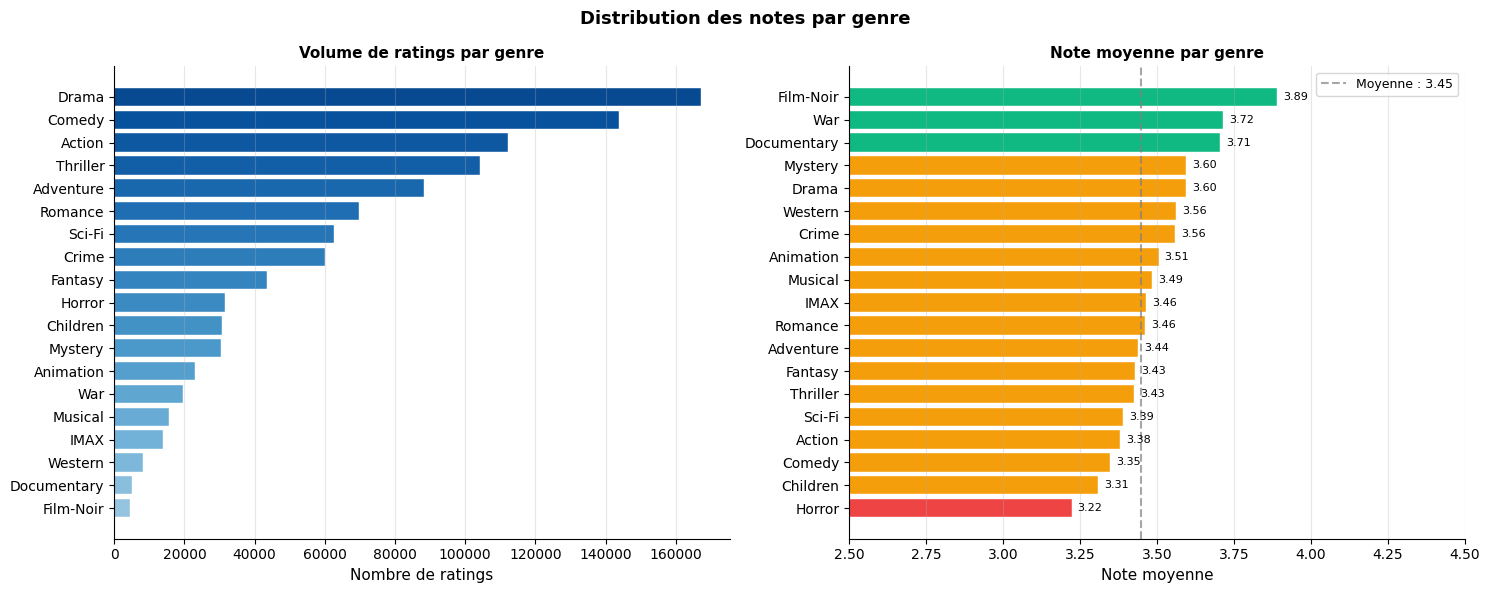

In [23]:
df_merged   = df_ratings.merge(df_items[['genres']], left_on=C.ITEM_ID_COL, right_index=True, how='left')
df_exploded = df_merged.assign(genre=df_merged['genres'].str.split('|')).explode('genre')
df_exploded = df_exploded[~df_exploded['genre'].isin(['(no genres listed)', ''])]
genre_stats = df_exploded.groupby('genre').agg(mean_rating=(C.RATING_COL, 'mean'), n_ratings=(C.RATING_COL, 'count')).sort_values('n_ratings', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Rating Distribution by Genre', fontsize=13, fontweight='bold')
ax1 = axes[0]
colors_g = plt.cm.Blues(np.linspace(0.4, 0.9, len(genre_stats)))[::-1]
ax1.barh(genre_stats['genre'], genre_stats['n_ratings'], color=colors_g, edgecolor='white', linewidth=0.3)
ax1.set_xlabel('Number of ratings', fontsize=11)
ax1.set_title('Rating volume per genre', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)
ax1.invert_yaxis()
ax2 = axes[1]
gs = genre_stats.sort_values('mean_rating', ascending=False)
cr = ['#10B981' if r >= 3.7 else '#F59E0B' if r >= 3.3 else '#EF4444' for r in gs['mean_rating']]
ax2.barh(gs['genre'], gs['mean_rating'], color=cr, edgecolor='white', linewidth=0.3)
ax2.axvline(df_ratings[C.RATING_COL].mean(), color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label=f"Global mean: {df_ratings[C.RATING_COL].mean():.2f}")
for i, (val, bar) in enumerate(zip(gs['mean_rating'], ax2.patches)):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
ax2.set_xlabel('Average rating', fontsize=11)
ax2.set_title('Average rating per genre', fontsize=11, fontweight='bold')
ax2.set_xlim(2.5, 4.5)
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)
ax2.invert_yaxis()
plt.tight_layout()
plt.show()


# 10 - Recommended Genres by Model

Genre distribution in iALS and BPR recommendations vs the catalogue.
Detects genre bias — a model may over-recommend certain genres
independently of user preferences.

**Reference:** Abdollahpouri et al. (2019, RecSys) · Deldjoo et al. (2021, ACM CSUR)

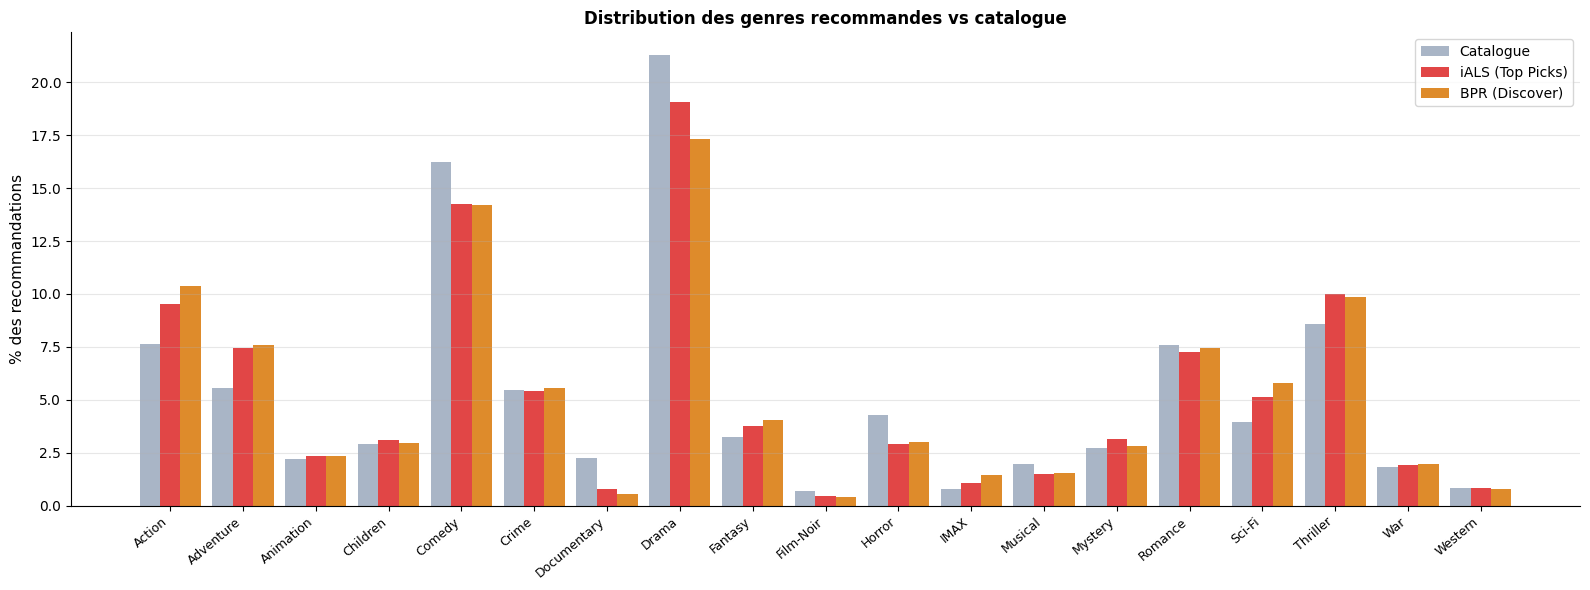

Ecart important entre Catalogue et modele = biais genre detecte.


In [24]:
from collections import Counter

def genre_dist(top_n, df_items):
    items  = [iid for recs in top_n.values() for iid, _ in recs]
    genres = []
    for iid in items:
        if iid in df_items.index:
            genres.extend([g for g in str(df_items.loc[iid, 'genres']).split('|') if g not in ['(no genres listed)', '']])
    counts = Counter(genres)
    total  = sum(counts.values())
    return {g: v/total*100 for g, v in counts.items()}

ials_g = genre_dist(ials_top_n, df_items)
bpr_g  = genre_dist(bpr_top_n,  df_items)
cat_g_all = [x for g in df_items['genres'].dropna() for x in str(g).split('|') if x not in ['(no genres listed)', '']]
cat_counts = Counter(cat_g_all)
cat_total  = sum(cat_counts.values())
cat_g = {g: v/cat_total*100 for g, v in cat_counts.items()}

all_genres = sorted(set(list(ials_g) + list(bpr_g) + list(cat_g)))
x = np.arange(len(all_genres))
w = 0.28
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w, [cat_g.get(g,0)  for g in all_genres], w, label='Catalogue',       color='#94A3B8', alpha=0.8)
ax.bar(x,     [ials_g.get(g,0) for g in all_genres], w, label='iALS (Top Picks)', color='#DC2626', alpha=0.85)
ax.bar(x + w, [bpr_g.get(g,0)  for g in all_genres], w, label='BPR (Discover)',   color='#D97706', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_genres, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('% des recommandations', fontsize=11)
ax.set_title('Distribution des genres recommandes vs catalogue', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print('Ecart important entre Catalogue et modele = biais genre detecte.')
